# Import functions

In [1]:
import warnings
warnings.filterwarnings("ignore", category=Warning, module="tqdm")
import sys
sys.path.append("../src")
from data_processing import clean_data
from train_model import model,make_confusion_matrix,get_metrics_score,run_shap_analysis
import pandas as pd
# import sys
# print(sys.executable)

# Import data

In [2]:
path = '../data/training_sample.csv'
# load dataframe
df = pd.read_csv(path)
df=clean_data(df)

Clean training data saved


# Check dataset shape

In [3]:
df.shape

(455401, 24)

# Inspect first 5 rows

In [4]:
df.head()

,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,closed_minibasket_click,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,0,1,0,1,0,0,0,0,1,0,...,0,0,0,1,0,0,1,0,1,1


# Load Model

In [5]:
#load clean data
path = '../data/final_version'
#load dataframe
final_data = pd.read_csv(path)
d_tree, X_train_res, y_train_res, X_test, y_test = model(final_data)

# Confusion matrix summary

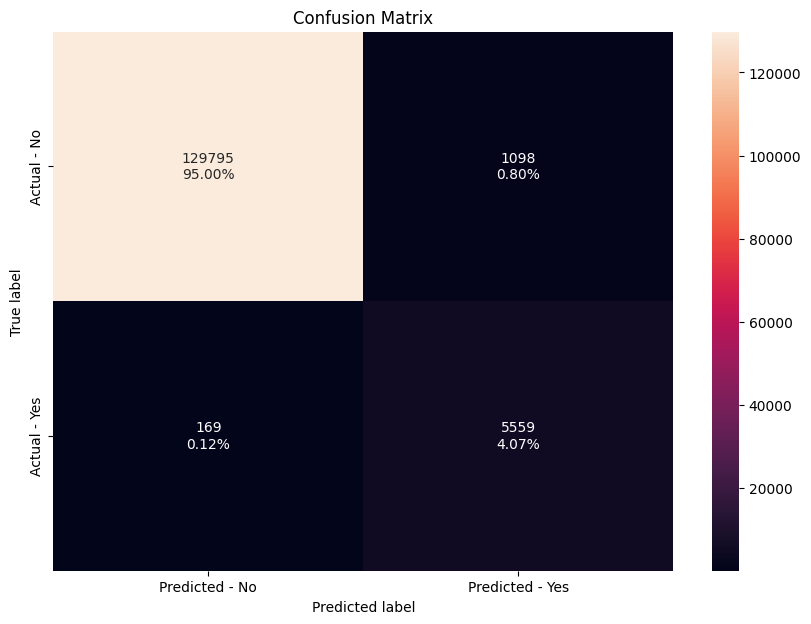

In [6]:
make_confusion_matrix(d_tree, y_test,X_test)

# Key takeaways:
* Model is very strong at catching buyers. 97.05% recall means it correctly identifies almost all customers who actually placed an order, missing very few true positives. Model missed only 169 buyers only.
* The precision of 83.51% means roughly 1 in 6 customers flagged as likely buyers won't actually convert.
* The 99.07% accuracy is impressive but slightly misleading on its own, as the dataset is likely imbalanced (most sessions don't result in a purchase). I plan using hyperparameter tuning here but the memory of my laptop is not capable to carry the load.

In [7]:
get_metrics_score(d_tree, X_train_res, y_train_res,X_test,y_test)

Accuracy on training set  :  99.43%
Accuracy on test set      :  99.07%
Recall on training set    :  99.58%
Recall on test set        :  97.05%
Precision on training set :  99.29%
Precision on test set     :  83.51%


SHAP values shape: (136621, 23, 2)


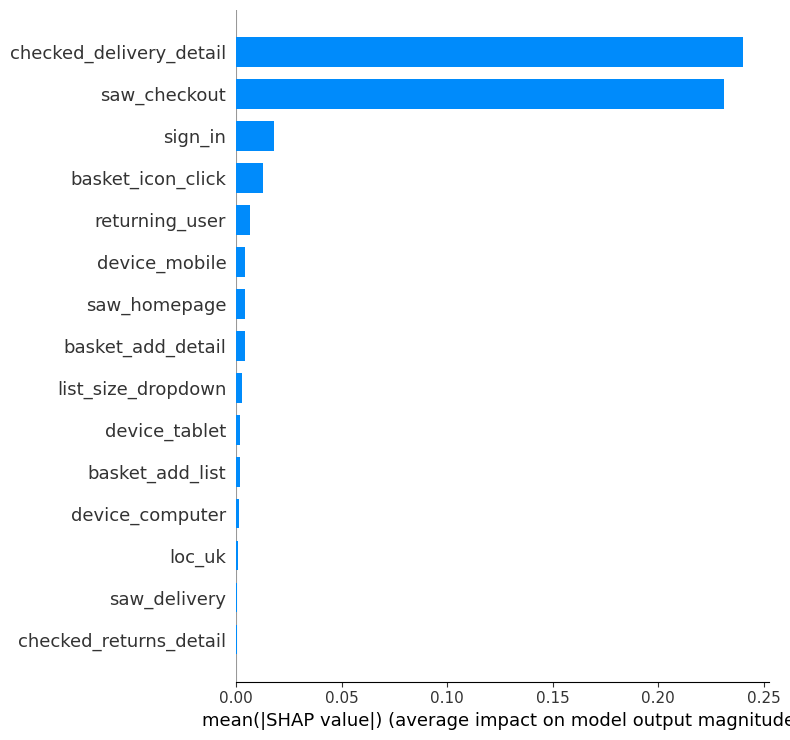

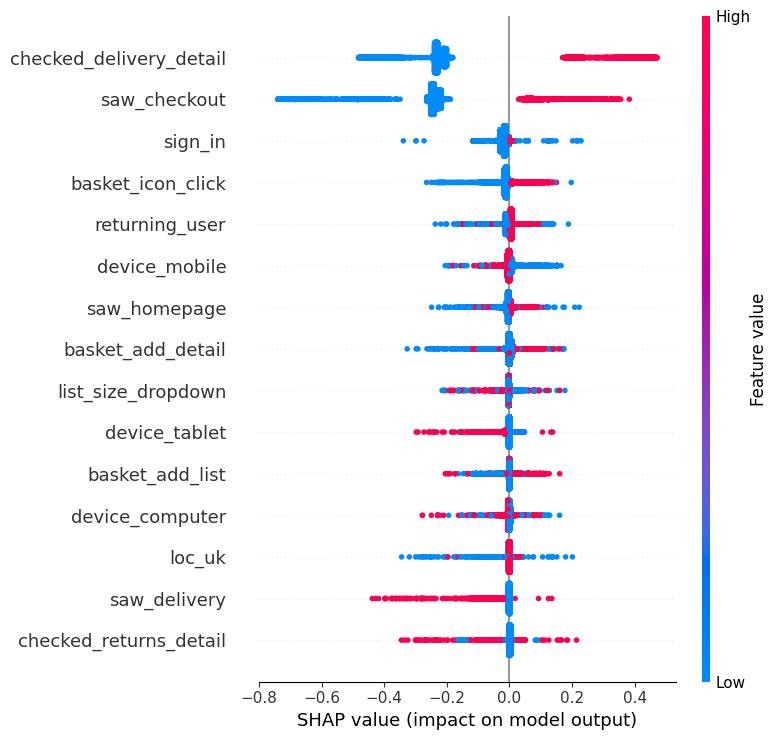

In [8]:
run_shap_analysis(d_tree,X_test)

# Recommendation and key takeaway
* Basket interactions are the dominant signal. Any marketing or UX intervention that encourages customers to add items to their basket will likely increase conversion rates.
* Returning users convert at higher rates,loyalty and re-engagement campaigns targeting returning visitors are likely to yield strong ROI.
* Comparison shopping behaviours (sort_by, detail_wishlist_add) are meaningful mid-funnel signals,these customers are engaged but undecided, making them prime candidates for targeted nudges such as price alerts or limited-time offers.
* Promotional banner clicks do not strongly predict purchase — click-through rate may be a poor proxy for conversion intent; consider optimising banners for downstream basket engagement rather than raw clicks.
# Risk 
* Periodic retraining is needed to maintain performance.


# Propensity to Buy — Model Demo

This notebook demonstrates the end-to-end pipeline for a customer propensity-to-buy model, 
predicting whether a user will place an order based on their browsing behaviour.

## Dataset
- **Shape:** 455,401 rows × 24 columns
- **Features:** Binary behavioural signals (e.g. `basket_add_list`, `sort_by`, `returning_user`, `loc_uk`)
- **Target:** `ordered` — whether the session resulted in a purchase

## Pipeline Steps
1. **Data Loading** — Load raw training sample from CSV
2. **Data Cleaning** — Apply preprocessing via `clean_data()`
3. **Model Training** — Train a Decision Tree classifier with SMOTE resampling via `model()`
4. **Evaluation** — Confusion matrix and key classification metrics
5. **Interpretability** — SHAP analysis to explain feature contributions

## Model Performance
| Metric    | Train   | Test    |
|-----------|---------|---------|
| Accuracy  | 99.43%  | 99.07%  |
| Recall    | 99.58%  | 97.05%  |
| Precision | 99.29%  | 83.51%  |

> **Note:** High recall on the test set (97.05%) ensures most likely buyers are captured,
> while the precision gap between train and test suggests some overfitting worth monitoring.